##### top

# FMP modelling for Figure 3 (Cue stimulus)

This notebook runs Bayesian models on Datasets 3 (dataset with randomising cue stimulus) that is described in the article to assess interaction between perception and memory difficulty levels in the FMP and to assess the effect of cue stimulus. We fit the following formulas to mean score within the condition. Throughout the notebook, I use `task` as a term for memory difficulty levels (M, UD, FD-e), `difficulty` as a term for perceptual difficulty levels (1, 2, 3), `target_loc_simple` as a categorical label for morphing status of the cue stimulus (unmorphed = `target_0`, morphed = `other`), and `userID` as a variable denoting individual participants. The reference levels are UD level 1 with morphed cue stimulus.


* Model task and difficulty interaction with user as a random effect. Add to it interaction with cue stimulus. Equation:
    * _"correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)"_
    
* Model interaction between all three variables (task, difficulty, cue stimulus)
    * _"correct_flt ~ task * difficulty * target_loc_simple + (1|userID)"_

* Model task and difficulty interaction with user as a random effect. Equation:
    * _correct_flt ~ task * difficulty + (1|userID)_
* Model task and difficulty as main effects without interaction with user as a random effect. Equation:
    * _correct_flt ~ task + difficulty + (1|userID)_



We model mean accuracy per participant per condition.


* [Models](#Models)
* [Plot results](#Plot-results)
* [Compare all data](#Compare-all-data)
* [Save the inference](#Save-the-inference)


In [1]:
import os, sys
import pickle
from os.path import join as opj
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
SEED = 7355608


# Importing module for functions
functions_modul =  "./functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from bayesian_modelling_functions import fit_model, print_model

path_general = "../"
path_data = opj(path_general, "Data", "datasets")
path_inference_data = opj(path_general, "Data", "model_inference_data")


# set the numer of CPU
num_cpu = min(4, os.cpu_count()-1)
print(f'We will have {num_cpu} cores.\n')


path_dic = {
#     'dataset_1' : opj(path_data, 'FMP_dataset_1.csv'),
#     'dataset_2': opj(path_data, 'FMP_dataset_2.csv'),
    'dataset_3': opj(path_data, 'FMP_dataset_3.csv'),
#     'concat_datasets_123': opj(path_data, 'FMP_concat_datasets_123.csv'),
#     'dataset_4': opj(path_data, 'FMP_dataset_4.csv'),
}


#####
# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 'math':'Filled Delay - math'}

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - math']


# load 
df_dataset_3 = pd.read_csv(opj(path_data, 'FMP_dataset_3.csv'))
# groupby and make means for ptc and condition
data = df_dataset_3.groupby(['userID', 'task', 'difficulty']).correct_flt.mean().reset_index()

# convert all variables to categories
# categorical_cols = data.columns[data.dtypes == object].tolist() + ['difficulty']
categorical_cols = ['userID', 'task', 'difficulty']
for col in categorical_cols:
    if col == 'task':
        # specify the order that we want
        data[col] = pd.Categorical(data[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
        #['Unfilled Delay', 'Matching', 'Filled Delay - emotions']

        # also do it for the original datasets
        df_dataset_3[col] = pd.Categorical(df_dataset_3[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)

    else:
        data[col] = data[col].astype("category")
        df_dataset_3[col] = df_dataset_3[col].astype("category")
data.info()

data.describe()
# data.dtypes


We will have 4 cores.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   userID       2358 non-null   category
 1   task         2358 non-null   category
 2   difficulty   2358 non-null   category
 3   correct_flt  2343 non-null   float64 
dtypes: category(3), float64(1)
memory usage: 38.2 KB


,correct_flt
count,2343.000000
mean,0.758141
std,0.147358
min,0.250000
25%,0.650000
50%,0.764706
75%,0.850000
max,1.000000


In [2]:
# drop them for now
data[data.correct_flt.isna()]

,userID,task,difficulty,correct_flt
90,s_1046,Filled Delay - emotions,1,NaN
91,s_1046,Filled Delay - emotions,2,NaN
92,s_1046,Filled Delay - emotions,3,NaN
135,s_1064,Filled Delay - emotions,1,NaN
136,s_1064,Filled Delay - emotions,2,NaN
137,s_1064,Filled Delay - emotions,3,NaN
963,s_429,Filled Delay - emotions,1,NaN
964,s_429,Filled Delay - emotions,2,NaN
965,s_429,Filled Delay - emotions,3,NaN
1602,s_691,Filled Delay - emotions,1,NaN


## Models
[top](#top)

In [3]:
model_assumptions = {
    "correct_flt ~ task * difficulty + (1|userID)": "Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.",
    "correct_flt ~ task + difficulty + (1|userID)": "Assumes that each user has their own baseline performance, but the effects of task and difficulty are consistent across all users without any interaction between task and difficulty.",
    "correct_flt ~ task * difficulty * target_loc_simple + (1|userID)": "Assumes that each user has their own baseline performance (random intercept), while the effects of task, difficulty, and target location (including all interactions between them) are consistent across all users.",
    "correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)":"Assumes that each user has their own baseline performance (random intercept), while the effects of task, difficulty, and the interaction between task and target location are consistent across all users. The interaction between task and difficulty is also considered, but target location only interacts with task, not difficulty.",
}

# define what we want to run
formulas2run = [
#     "correct_flt ~ task * difficulty * target_loc_simple + (1|userID)",
#     "correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)",
    "correct_flt ~ task * difficulty + (1|userID)",
    "correct_flt ~ task + difficulty + (1|userID)",
]

In [4]:
# define where we will store the results
model_dic = {}
result_dic = {}

for formula in formulas2run:
    print(f'\nFitting formula {formula}\n-> {model_assumptions[formula]}\n')

#     tmp_model, tmp_result = None, None
    
    model_dic[formula], result_dic[formula] = fit_model(formula, data, categorical_cols, num_cpu=num_cpu,
                                      check_priors=False, sample_priors=False)
    
    
    
#     print('\n------------------------')

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:19

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


In [5]:
# add the target loc
formula = "correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)"

model_dic[formula], result_dic[formula] = fit_model(formula, 
                                                    data=df_dataset_3.groupby(['userID', 'task', 'difficulty', 'target_loc_simple']).correct_flt.mean().reset_index(), 
                                                    categorical_cols = ['userID', 'task', 'difficulty', 'target_loc_simple'],
                                                    num_cpu=num_cpu,
                                                    # increase the tuning a little bit to help R_hat
                                                    fit_kwargs={"tune":1300},
                                  check_priors=False, sample_priors=False)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:36

Sampling 4 chains for 1_300 tune and 1_000 draw iterations (5_200 + 4_000 draws total) took 37 seconds.


In [6]:
# and the second formula
formula = "correct_flt ~ task * difficulty * target_loc_simple + (1|userID)"
    
model_dic[formula], result_dic[formula] = fit_model(formula, 
                                                    data=df_dataset_3.groupby(['userID', 'task', 'difficulty', 'target_loc_simple']).correct_flt.mean().reset_index(), 
                                                    categorical_cols = ['userID', 'task', 'difficulty', 'target_loc_simple'],
                                                    num_cpu=num_cpu,
                                  check_priors=False, sample_priors=False)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:40

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.


In [7]:
model_dic["correct_flt ~ task * difficulty * target_loc_simple + (1|userID)"]

       Formula: correct_flt ~ task * difficulty * target_loc_simple + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 4685
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7496, sigma: 1.2349)
            task ~ Normal(mu: [0. 0.], sigma: [1.1124 1.118 ])
            difficulty ~ Normal(mu: [0. 0.], sigma: [1.1144 1.1142])
            task:difficulty ~ Normal(mu: [0. 0. 0. 0.], sigma: [1.6666 1.6666 1.6821 1.6807])
            target_loc_simple ~ Normal(mu: 0.0, sigma: 1.0505)
            task:target_loc_simple ~ Normal(mu: [0. 0.], sigma: [1.4057 1.4166])
            difficulty:target_loc_simple ~ Normal(mu: [0. 0.], sigma: [1.4093 1.4093])
            task:difficulty:target_loc_simple ~ Normal(mu: [0. 0. 0. 0.], sigma: [2.286  2.286  2.3069
                2.3069])
        
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.2349))
        
        Au


Printing formula correct_flt ~ task * difficulty + (1|userID)
-> Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.



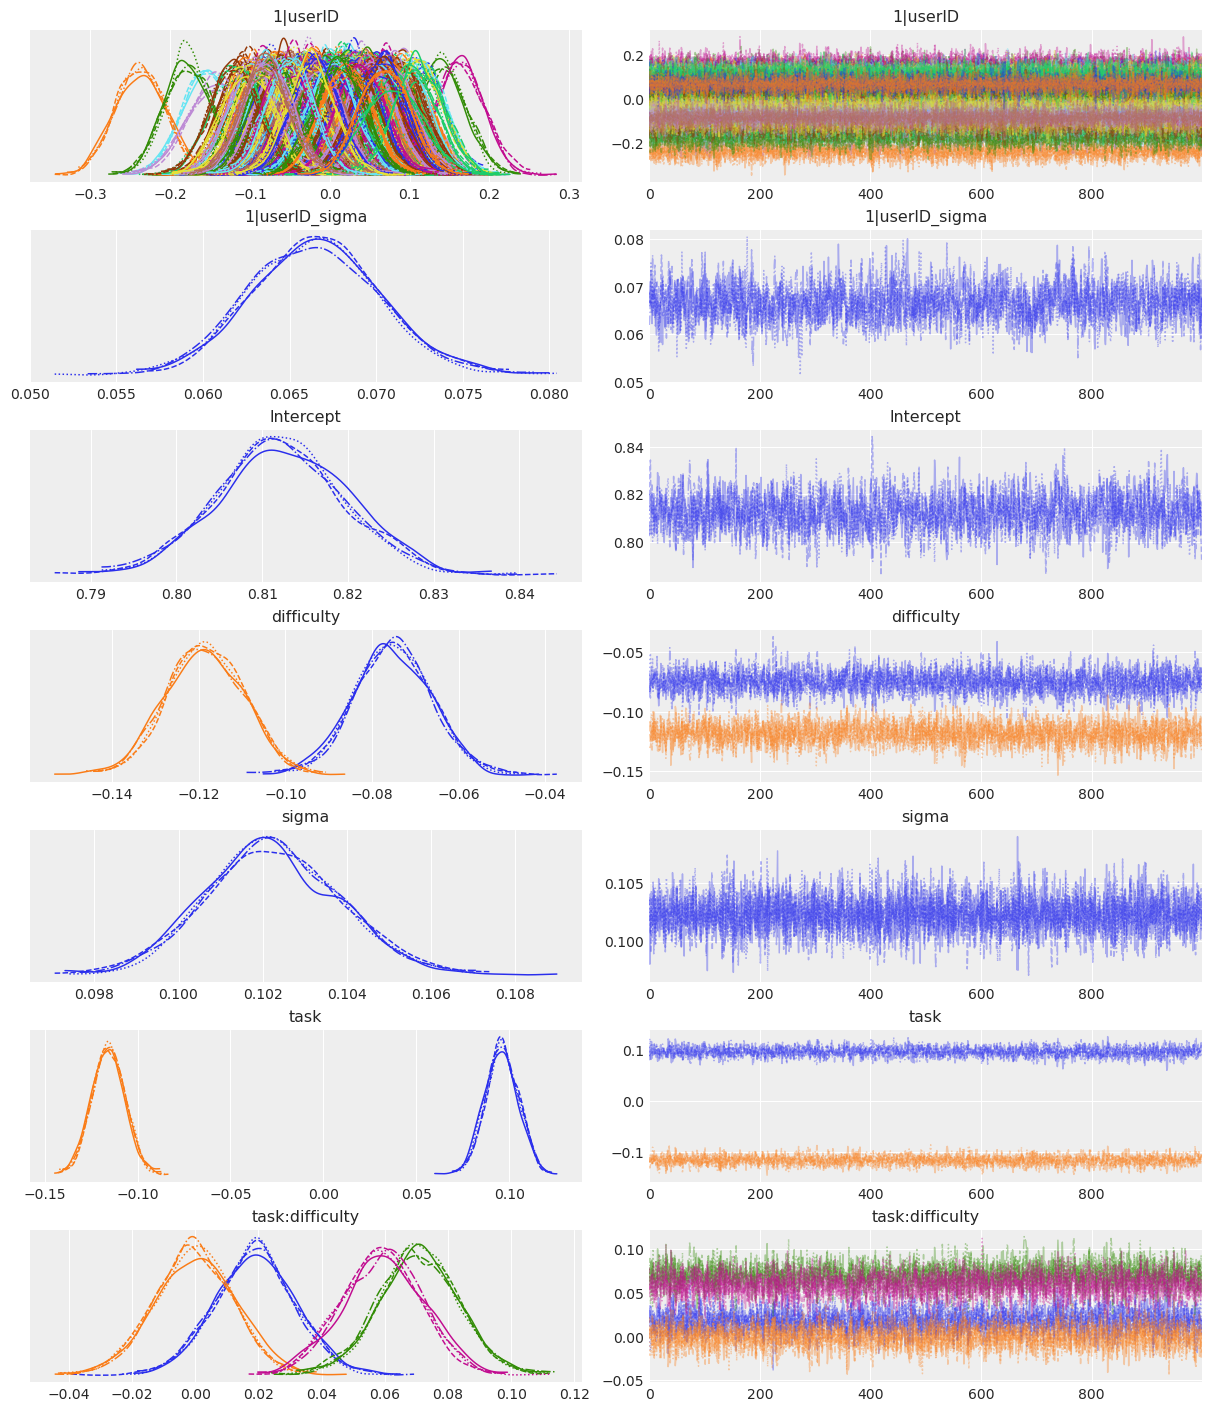

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.023  0.031  -0.033    0.084        0.0    0.000    8050.0   
1|userID[s_1002] -0.094  0.031  -0.151   -0.035        0.0    0.000    9510.0   
1|userID[s_1006]  0.031  0.031  -0.025    0.088        0.0    0.000    7119.0   
1|userID[s_1012] -0.027  0.030  -0.083    0.032        0.0    0.000    8329.0   
1|userID[s_1015] -0.011  0.030  -0.068    0.047        0.0    0.000    7765.0   
1|userID[s_1016]  0.015  0.030  -0.043    0.072        0.0    0.001    7577.0   
1|userID[s_1017] -0.051  0.030  -0.106    0.005        0.0    0.000    8307.0   
1|userID[s_1036]  0.031  0.031  -0.026    0.092        0.0    0.000    7114.0   
1|userID[s_1042] -0.003  0.030  -0.059    0.054        0.0    0.001    7748.0   
1|userID[s_1045]  0.051  0.030  -0.009    0.105        0.0    0.000    7672.0   
1|userID[s_1046] -0.017  0.036  -0.086    0.046        0.0    0.001    8342.0   
1|userID[s_1047]  0.011  0.0

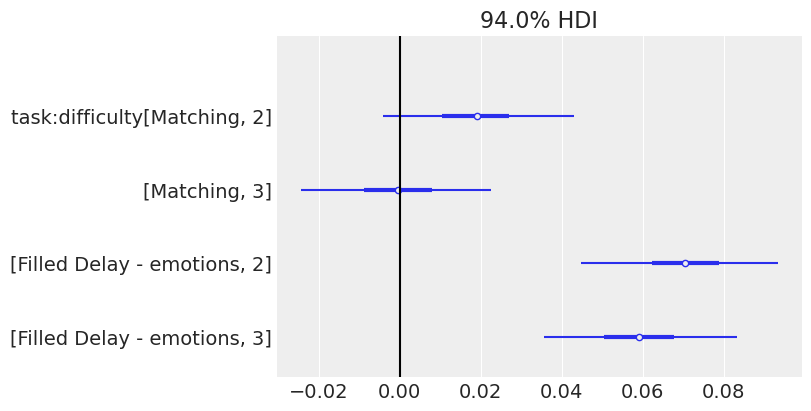

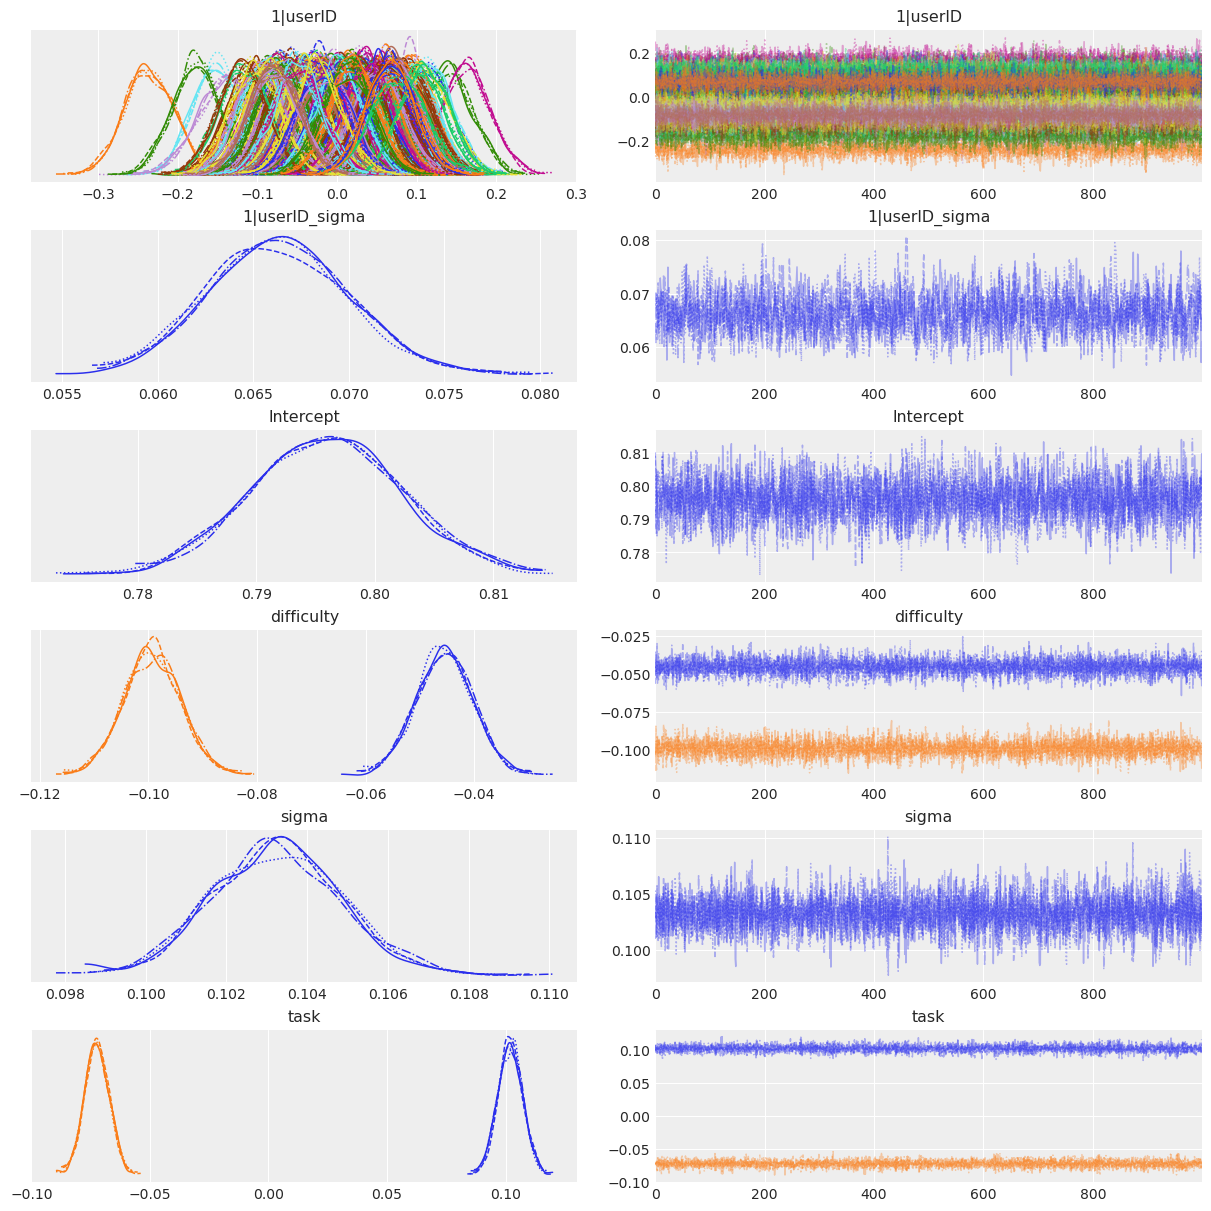

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.023  0.031  -0.037    0.082        0.0    0.000    8251.0   
1|userID[s_1002] -0.094  0.031  -0.152   -0.038        0.0    0.000    7861.0   
1|userID[s_1006]  0.031  0.031  -0.026    0.089        0.0    0.000    8825.0   
1|userID[s_1012] -0.027  0.030  -0.085    0.028        0.0    0.000    7556.0   
1|userID[s_1015] -0.010  0.031  -0.071    0.048        0.0    0.001    8957.0   
1|userID[s_1016]  0.015  0.030  -0.042    0.072        0.0    0.000    8321.0   
1|userID[s_1017] -0.050  0.031  -0.107    0.007        0.0    0.000    8654.0   
1|userID[s_1036]  0.032  0.032  -0.033    0.087        0.0    0.000    9049.0   
1|userID[s_1042] -0.002  0.031  -0.056    0.063        0.0    0.001    7195.0   
1|userID[s_1045]  0.051  0.031  -0.008    0.108        0.0    0.000    9198.0   
1|userID[s_1046] -0.017  0.036  -0.085    0.050        0.0    0.001    8238.0   
1|userID[s_1047]  0.011  0.0

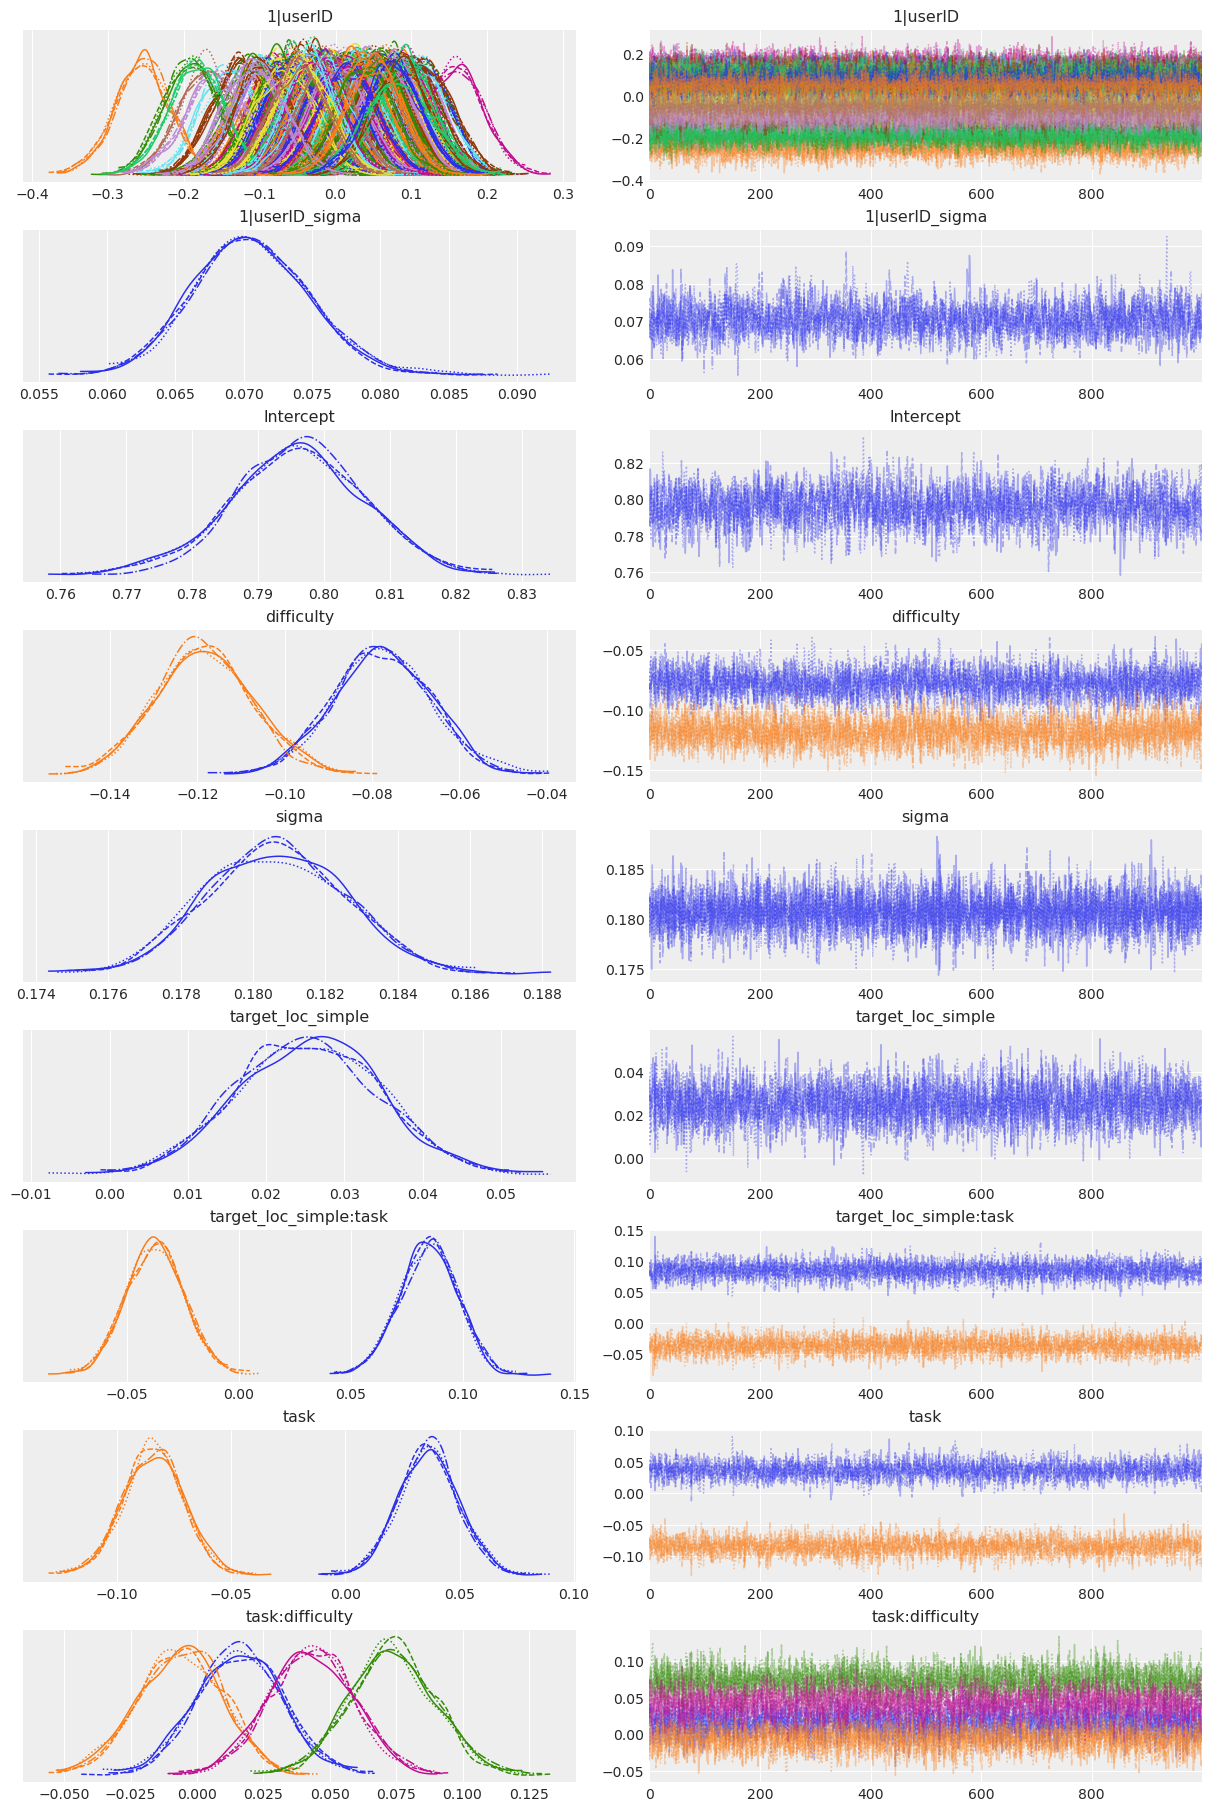

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.023  0.037  -0.046    0.094        0.0    0.001    7305.0   
1|userID[s_1002] -0.081  0.038  -0.157   -0.016        0.0    0.000    7973.0   
1|userID[s_1006]  0.034  0.036  -0.033    0.104        0.0    0.000    8237.0   
1|userID[s_1012] -0.050  0.036  -0.116    0.018        0.0    0.000   10594.0   
1|userID[s_1015] -0.006  0.037  -0.079    0.060        0.0    0.001    8852.0   
1|userID[s_1016]  0.021  0.037  -0.045    0.090        0.0    0.001    9449.0   
1|userID[s_1017] -0.067  0.037  -0.133    0.009        0.0    0.000    9863.0   
1|userID[s_1036]  0.006  0.036  -0.064    0.072        0.0    0.001    8944.0   
1|userID[s_1042] -0.046  0.037  -0.116    0.020        0.0    0.000    9696.0   
1|userID[s_1045]  0.068  0.037  -0.001    0.136        0.0    0.000   10542.0   
1|userID[s_1046] -0.032  0.041  -0.113    0.044        0.0    0.001    8675.0   
1|userID[s_1047]  0.031  0.0

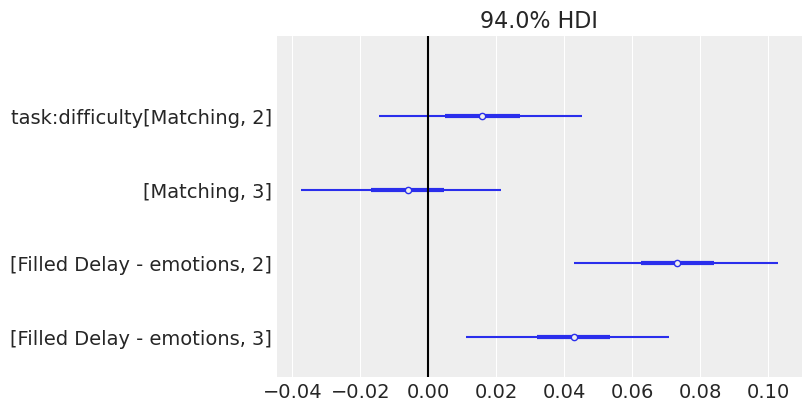

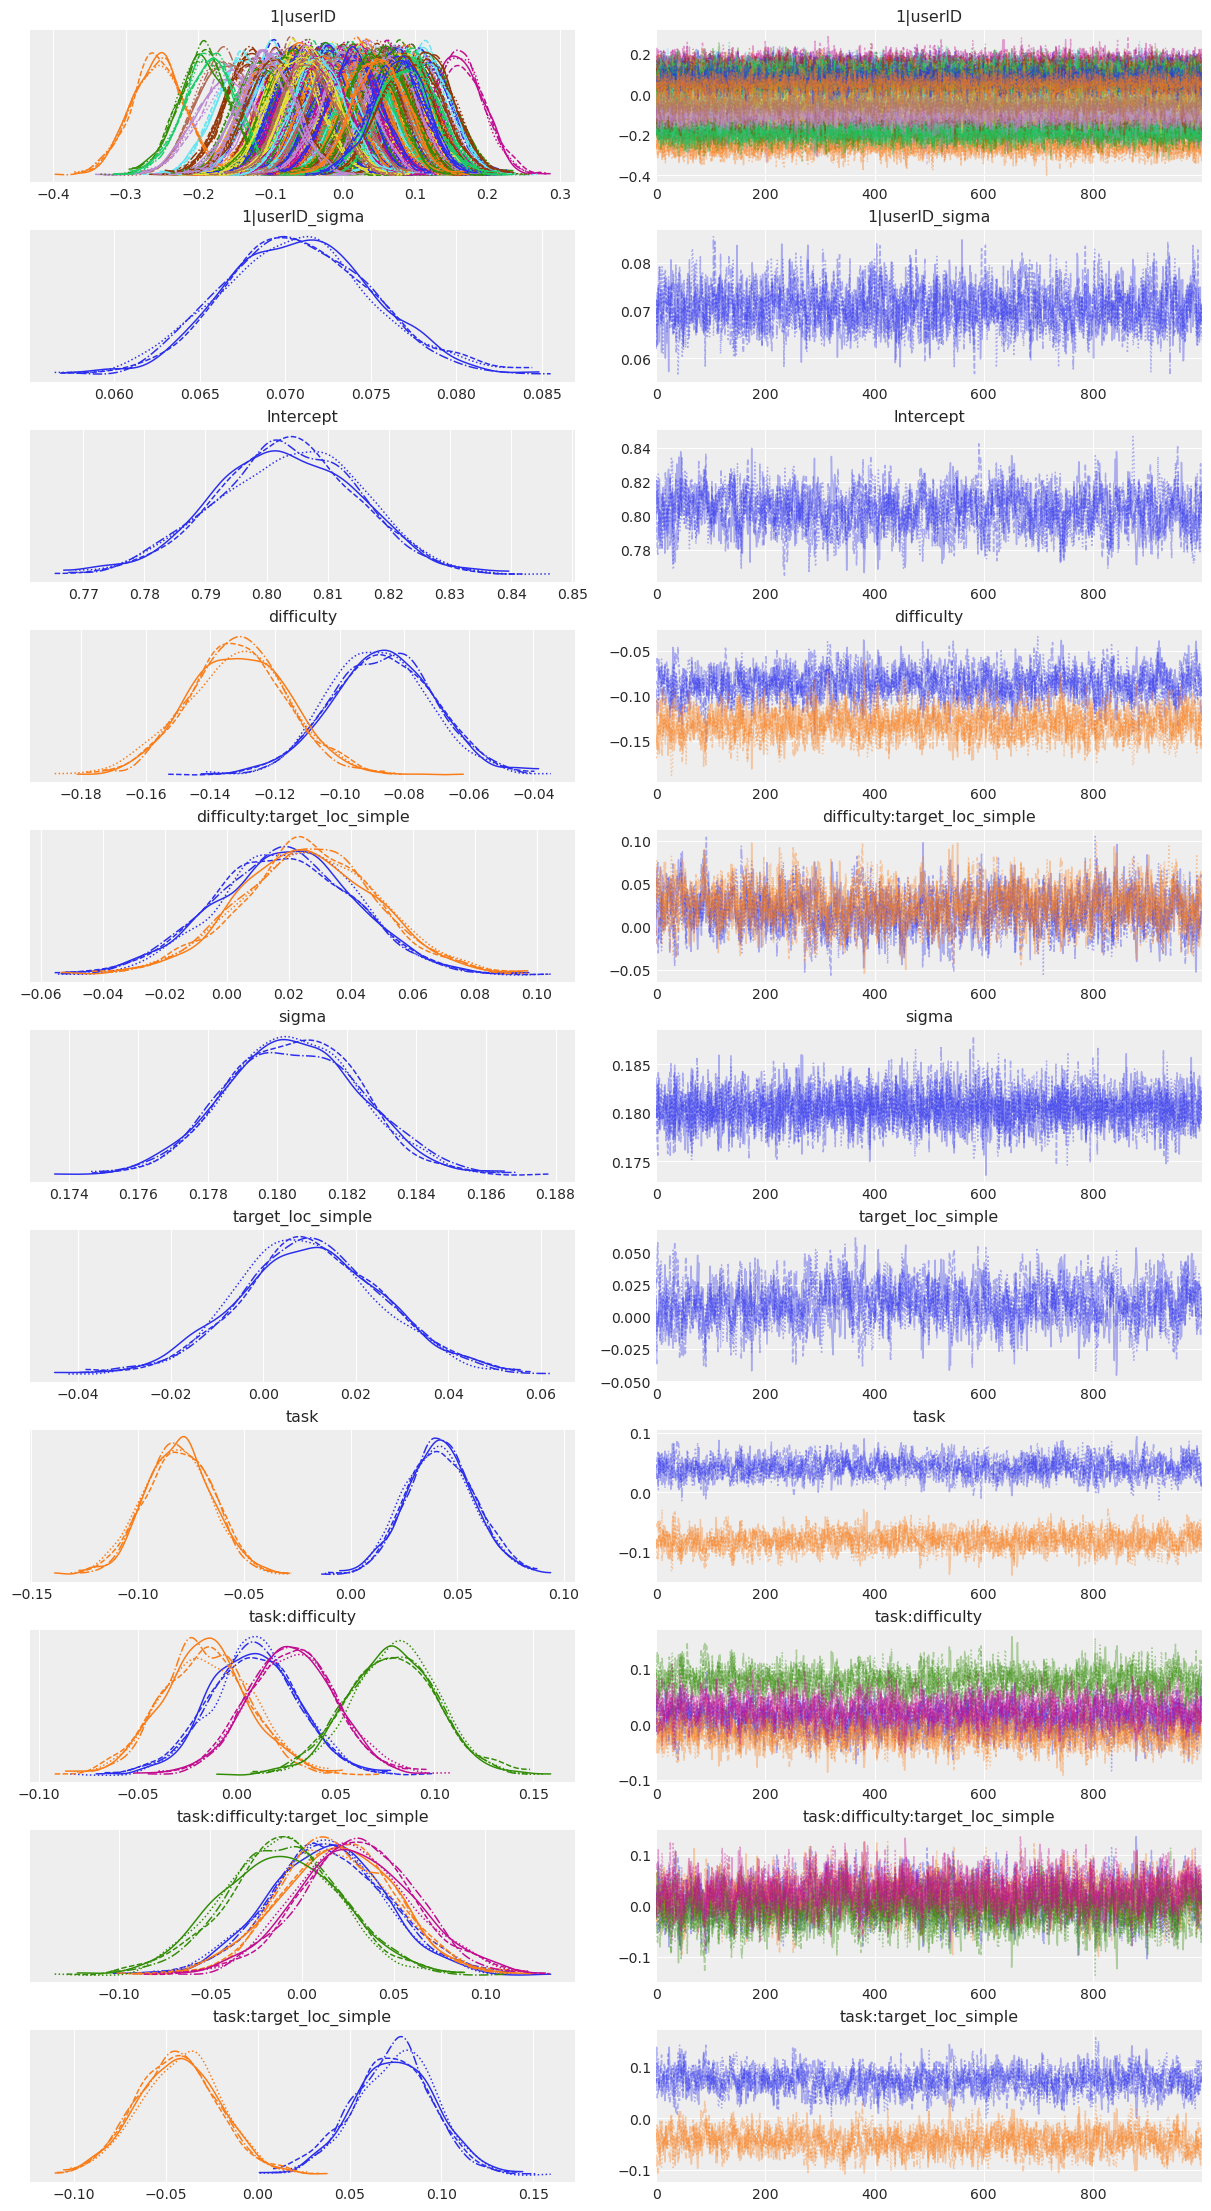

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.024  0.037  -0.049    0.091      0.001    0.001    4520.0   
1|userID[s_1002] -0.081  0.037  -0.149   -0.009      0.001    0.000    4297.0   
1|userID[s_1006]  0.035  0.036  -0.029    0.107      0.001    0.000    4646.0   
1|userID[s_1012] -0.051  0.036  -0.118    0.017      0.001    0.000    4814.0   
1|userID[s_1015] -0.005  0.036  -0.072    0.064      0.001    0.001    4185.0   
1|userID[s_1016]  0.022  0.036  -0.045    0.089      0.001    0.000    4825.0   
1|userID[s_1017] -0.067  0.037  -0.138   -0.002      0.000    0.000    5962.0   
1|userID[s_1036]  0.006  0.037  -0.064    0.074      0.001    0.001    4817.0   
1|userID[s_1042] -0.047  0.037  -0.112    0.026      0.001    0.000    4847.0   
1|userID[s_1045]  0.068  0.036  -0.001    0.136      0.001    0.000    4901.0   
1|userID[s_1046] -0.033  0.042  -0.115    0.043      0.001    0.001    4723.0   
1|userID[s_1047]  0.032  0.0

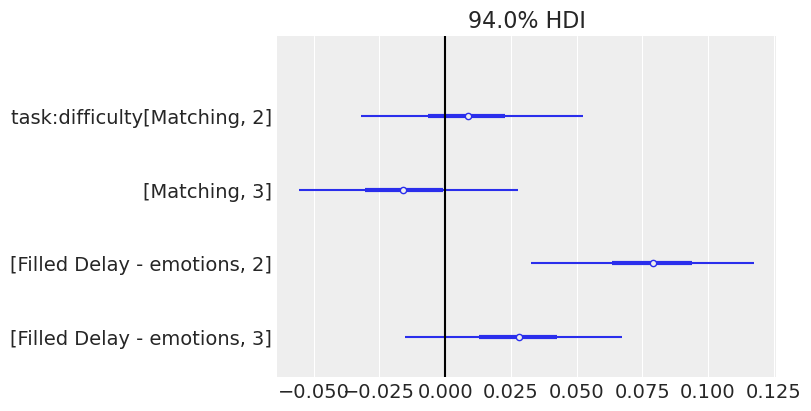

In [8]:
# print the model

for formula in list(model_dic.keys()):
    print(f'\nPrinting formula {formula}\n-> {model_assumptions[formula]}\n')

    print_model(model_dic[formula], result_dic[formula])
    
    print('\n------------------------')

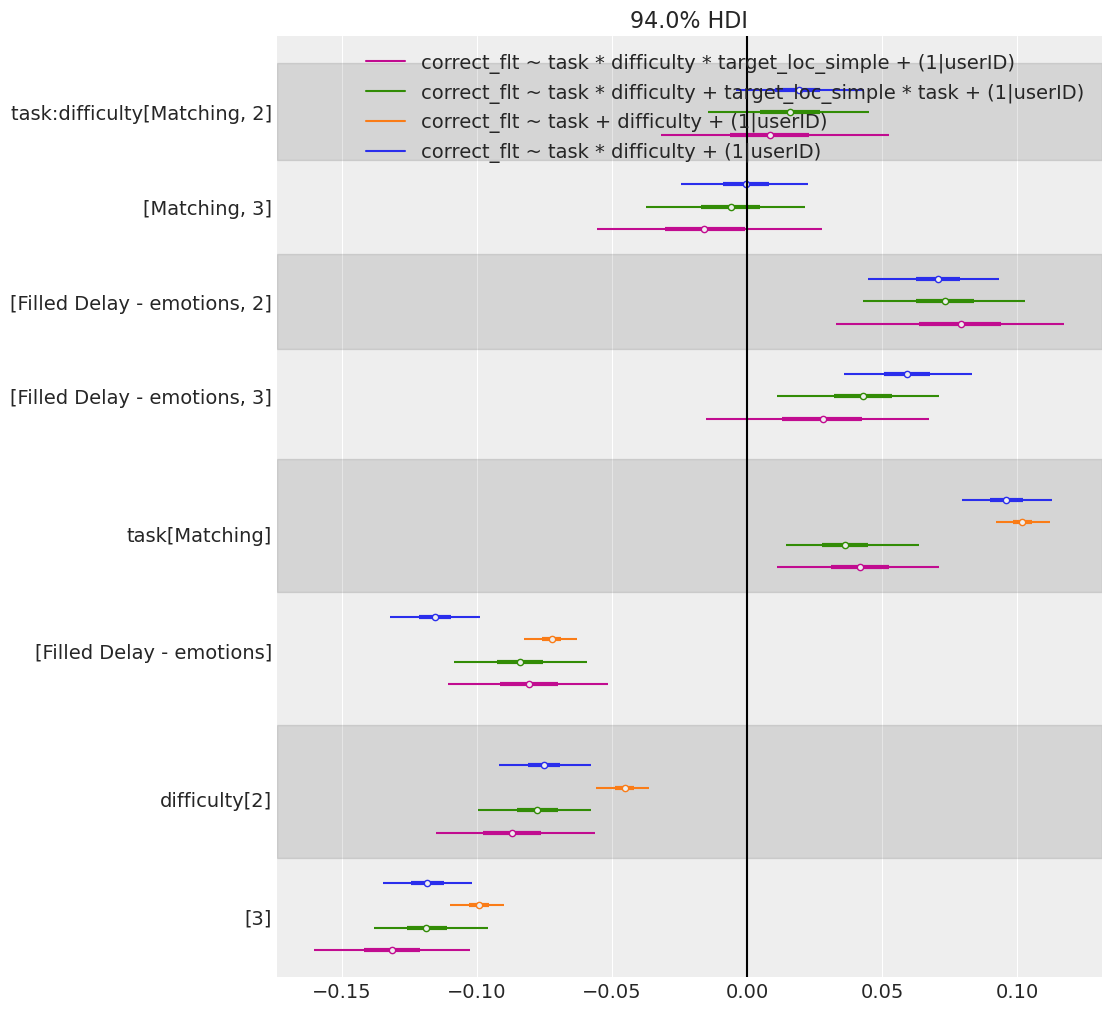

In [9]:
az.plot_forest(
    list(result_dic.values()),
    model_names=list(model_dic.keys()), 
    var_names=["task:difficulty", "task", "difficulty"],
    combined=True,
    figsize=(11, 10),
)

plt.axvline(0, c='k');

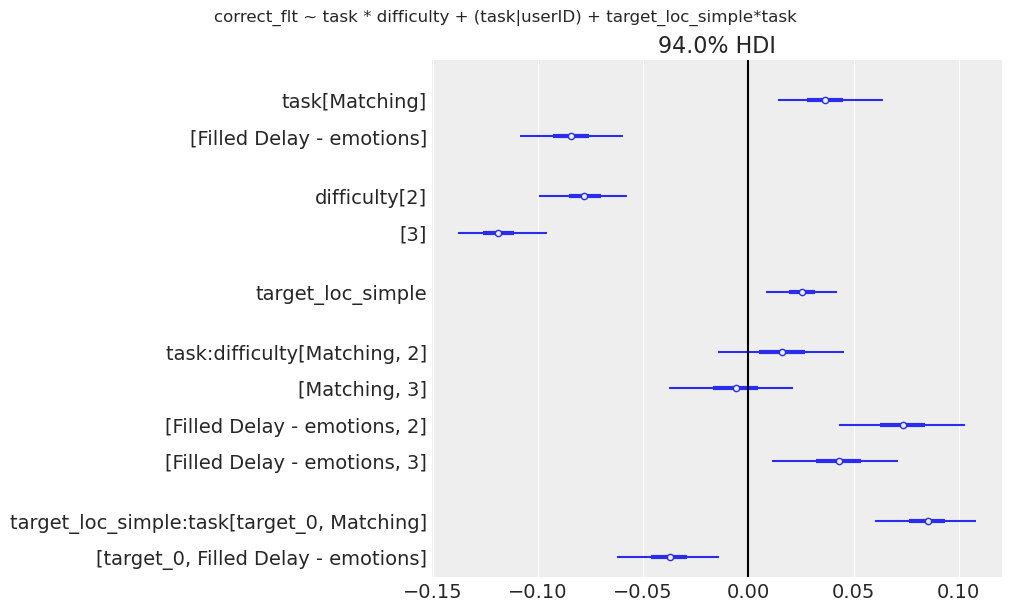

In [10]:
az.plot_forest(
    result_dic['correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)'],
#     model_names=['correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task'],#list(model_assumptions.keys()),
    var_names=["task", "difficulty", "target_loc_simple", "task:difficulty", "target_loc_simple:task"],
    combined=True,
    figsize=(10, 6),
)

plt.axvline(0, c='k')

plt.suptitle('correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task');


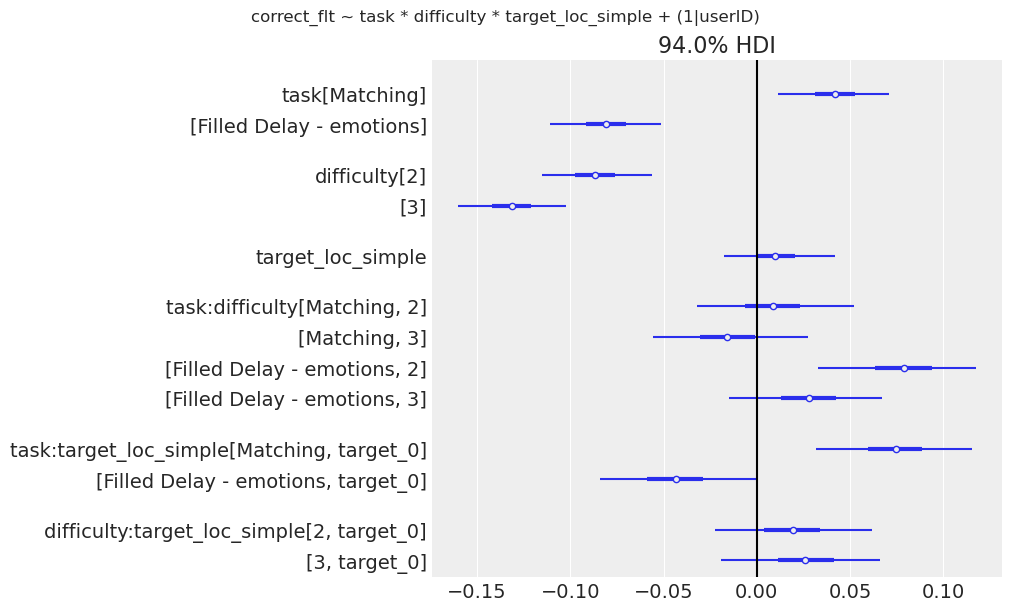

In [11]:
formula = 'correct_flt ~ task * difficulty * target_loc_simple + (1|userID)'
az.plot_forest(
    result_dic[formula],
#     model_names=['correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task'],#list(model_assumptions.keys()),
    var_names=["task", "difficulty", "target_loc_simple", "task:difficulty", "task:target_loc_simple", "difficulty:target_loc_simple"],
    combined=True,
    figsize=(10, 6),
)

plt.axvline(0, c='k')

plt.suptitle(f'{formula}');


### Compare all data
[top](#top)

In [12]:

new_results = {}
for f in result_dic.keys():
#     if f!='correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task':
    if f!='correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)' and f!='correct_flt ~ task * difficulty * target_loc_simple + (1|userID)':
        new_results[f] = result_dic[f]

df_compare_formulas = az.compare(new_results)
df_compare_formulas



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
correct_flt ~ task * difficulty + (1|userID),0,1904.356989,208.900273,0.000000,0.837425,35.390395,0.000000,False,log
correct_flt ~ task + difficulty + (1|userID),1,1886.340176,203.053345,18.016813,0.162575,35.646999,7.337876,False,log


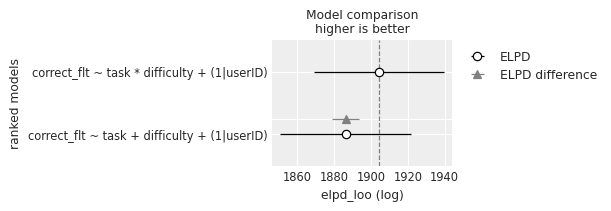

In [13]:
az.plot_compare(df_compare_formulas, insample_dev=False);

---

### Predictions
[top](#top)

/home/labs/paz/janka/.conda/envs/pymc_env_5/lib/python3.12/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for conditional variable: difficulty
Default computed for unspecified variable: task, userID


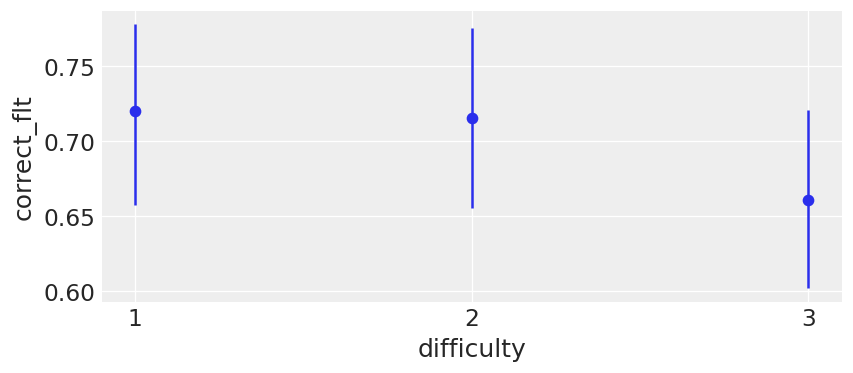

In [14]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model_dic["correct_flt ~ task * difficulty + (1|userID)"], 
                               result_dic["correct_flt ~ task * difficulty + (1|userID)"], "difficulty", ax=ax);

/home/labs/paz/janka/.conda/envs/pymc_env_5/lib/python3.12/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for conditional variable: difficulty, task
Default computed for unspecified variable: userID


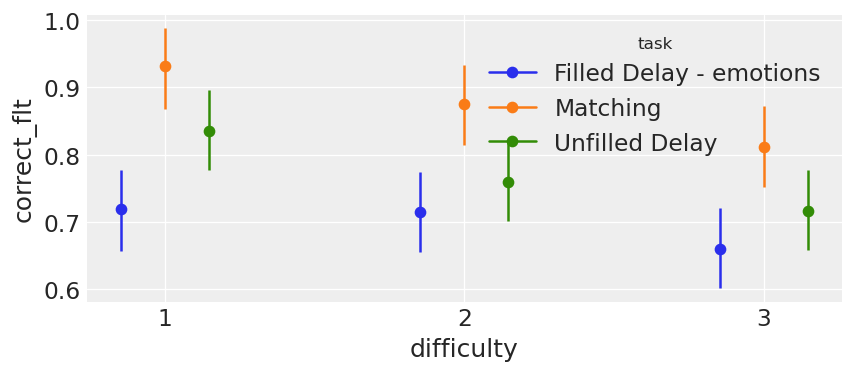

In [15]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model_dic["correct_flt ~ task * difficulty + (1|userID)"], 
                               result_dic["correct_flt ~ task * difficulty + (1|userID)"], 
                               ["difficulty","task"], ax=ax);

/home/labs/paz/janka/.conda/envs/pymc_env_5/lib/python3.12/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for unspecified variable: userID


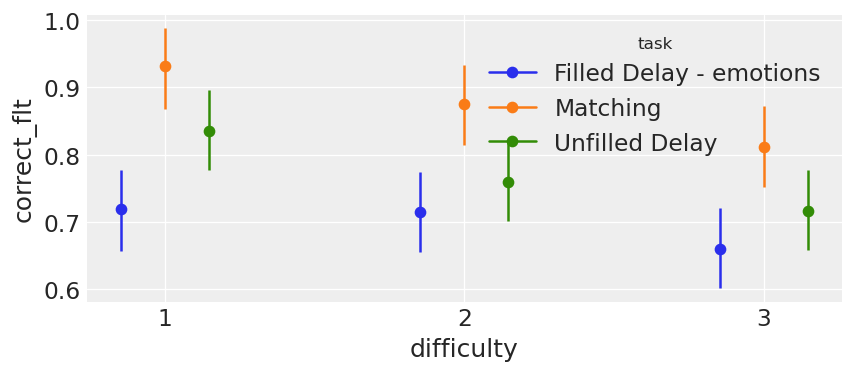

In [16]:
hue_order = ["Matching", "Unfilled Delay", "Filled Delay - emotions"]

fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(
    model_dic["correct_flt ~ task * difficulty + (1|userID)"], 
    result_dic["correct_flt ~ task * difficulty + (1|userID)"],
    conditional={
        "difficulty": [1,2,3],
        "task": hue_order,
    }, 
    ax=ax,
#     subplot_kwargs={"hue_order":hue_order}
    
);

In [17]:
summary_df = bmb.interpret.predictions(
    model_dic["correct_flt ~ task * difficulty + (1|userID)"], 
    result_dic["correct_flt ~ task * difficulty + (1|userID)"], 
    conditional=["difficulty","task"],
)
summary_df#.head()

/home/labs/paz/janka/.conda/envs/pymc_env_5/lib/python3.12/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for conditional variable: difficulty, task
Default computed for unspecified variable: userID


,difficulty,task,userID,estimate,lower_3.0%,upper_97.0%
0,1,Filled Delay - emotions,s_1001,0.719610,0.657286,0.777579
1,1,Matching,s_1001,0.931184,0.868354,0.988705
2,1,Unfilled Delay,s_1001,0.835234,0.777005,0.895479
3,2,Filled Delay - emotions,s_1001,0.715022,0.654995,0.774880
4,2,Matching,s_1001,0.874862,0.814519,0.933568
5,2,Unfilled Delay,s_1001,0.760009,0.701798,0.819933
6,3,Filled Delay - emotions,s_1001,0.660249,0.601541,0.720419
7,3,Matching,s_1001,0.812212,0.752867,0.872041
8,3,Unfilled Delay,s_1001,0.716758,0.658396,0.777140


/home/labs/paz/janka/.conda/envs/pymc_env_5/lib/python3.12/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for conditional variable: difficulty, task
Default computed for unspecified variable: userID


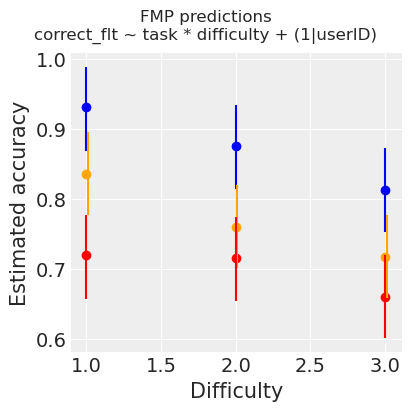

In [18]:
import seaborn as sns

colour_map = {
    'Matching' : 'blue',
    'Unfilled Delay': 'orange',
    'Filled Delay - emotions': 'red',
}

model_name = "correct_flt ~ task * difficulty + (1|userID)"
summary_df = bmb.interpret.predictions(
    model_dic[model_name], 
    result_dic[model_name], 
    conditional=["difficulty","task"],
)

fig, ax = plt.subplots(figsize=(4, 4))

# sns.barplot(x='difficulty', y='estimate', data=summary_df,
#                 hue='task', hue_order=hue_order,
# #                 palette=flattened_palette, edgecolor='k',
#                     ax=ax,
#                )

for i,tsk in enumerate(hue_order):

    ax.scatter(data=summary_df.loc[summary_df['task']==tsk],
               x="difficulty", y="estimate",
               color=f"{colour_map[tsk]}",
              )
    for d in summary_df['difficulty'].unique():
        ax.vlines(d+0.01*(i%2), 
                  summary_df.loc[(summary_df['task']==tsk)&(summary_df['difficulty']==d), "lower_3.0%"].iloc[0],
                  summary_df.loc[(summary_df['task']==tsk)&(summary_df['difficulty']==d), "upper_97.0%"].iloc[0],
                  color=f"{colour_map[tsk]}",
                 )


ax.set_xlabel('Difficulty')
ax.set_ylabel('Estimated accuracy')
plt.suptitle(f'FMP predictions\n{model_name}')
plt.show()

### Save the inference
[top](#top)


In [19]:

# save the dictionary to a pickle file
with open(opj(path_inference_data,'FMP_cue_stimulus_inference_data_dict.pkl'), 'wb') as f:
    pickle.dump(result_dic, f)

# # Load the dictionary from the pickle file
# with open(opj(path_inference_data,'FMP_cue_stimulus_inference_data_dict.pkl'), 'rb') as f:
#     loaded_inference_data_dict = pickle.load(f)


In [20]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv -iv -w -p pytensor


Author: Jan Kadlec

Last updated: Fri May 16 2025

Python implementation: CPython
Python version       : 3.12.5
IPython version      : 8.25.0

pytensor: 2.23.0

Compiler    : GCC 12.4.0
OS          : Linux
Release     : 5.14.0-427.42.1.el9_4.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

pandas    : 2.2.2
seaborn   : 0.13.2
bambi     : 0.14.0
numpy     : 1.26.4
matplotlib: 3.9.2
sys       : 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:36:51) [GCC 12.4.0]
arviz     : 0.19.0

Watermark: 2.4.3



[top](#top)